In [1]:
# Импорт библиотек
import os
import math
import time
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torch.utils.data import Dataset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets.utils import download_url, extract_archive

from torchvision import datasets

from PIL import Image

from dataclasses import dataclass
import tarfile
import shutil

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

FAST_MODE = False  
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
Device: cuda


Mean: tensor([0.4467, 0.4398, 0.4066])
Std: tensor([0.2242, 0.2215, 0.2239])
classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
train size: 5000
test size: 8000
weights: ResNet18_Weights.IMAGENET1K_V1
x_batch: torch.Size([128, 3, 96, 96]) torch.float32
y_batch: torch.Size([128]) torch.int64


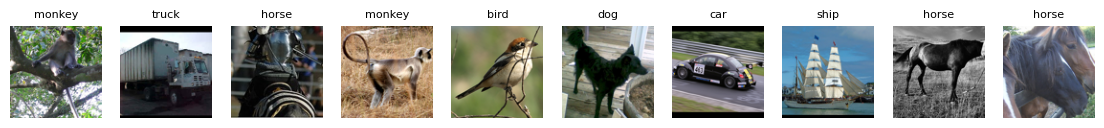

In [2]:
# Часть A

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# Загружаем датасет БЕЗ нормализации (только ToTensor)
train_ds_raw = datasets.STL10(
    root="./data", split="train", download=True,
    transform=transforms.ToTensor()
)

loader = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# Считаем mean и std
mean_sum = 0.0
std_sum = 0.0
nb_samples = 0

for data, _ in loader:
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)
    mean_sum += data.mean(2).sum(0)
    std_sum += data.std(2).sum(0)
    nb_samples += batch_samples

# Вычисляем финальные значения
stl_mean = mean_sum / nb_samples
stl_std = std_sum / nb_samples

print(f"Mean: {stl_mean}")
print(f"Std: {stl_std}")

# Базовый transform для CNN
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=stl_mean.tolist(),
        std=stl_std.tolist()
    )
])

# Transform с аугментациями
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=stl_mean.tolist(),
        std=stl_std.tolist()
    )
])

# Transform для предобученного ResNet
transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])


# Загружаем датасет с правильной нормализацией
train_full_basic = datasets.STL10(
    root="./data", split="train", download=False,
    transform=transform_basic
)

train_full_aug = datasets.STL10(
    root="./data", split="train", download=False,
    transform=transform_augmented
)

test_ds = datasets.STL10(
    root = "./data", split="test", download=False,
    transform=transform_basic
)

train_full_resnet = datasets.STL10(
    root="./data", split="train", download=False,
    transform=transform_resnet
)

class_names = train_full_basic.classes
print("classes:", class_names)
print("train size:", len(train_full_basic))
print("test size:", len(test_ds))

# Создаём функции для визуализации
def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = stl_mean.view(3, 1, 1).to(x.device)
    std = stl_std.view(3, 1, 1).to(x.device)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

# train/val split

val_ratio = 0.1
val_size = int(len(train_full_basic) * val_ratio)
train_size = len(train_full_basic) - val_size

gen = torch.Generator().manual_seed(42)
# Для C1 и теста
train_ds_basic, val_ds_basic = random_split(
    train_full_basic, [train_size, val_size], 
    generator=gen
)

# Для C2 (аугментации)
train_ds_aug, val_ds_aug = random_split(
    train_full_aug, [train_size, val_size], 
    generator=gen
)

# Для C3/C4 (ResNet)
train_ds_resnet, val_ds_resnet = random_split(
    train_full_resnet, [train_size, val_size], 
    generator=gen
)

# DataLoader

# C1: базовый
train_loader_basic = DataLoader(
    train_ds_basic, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader_basic = DataLoader(
    val_ds_basic, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# C2: с аугментациями
train_loader_aug = DataLoader(
    train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader_aug = DataLoader(
    val_ds_aug, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# C3/C4: ResNet
train_loader_resnet = DataLoader(
    train_ds_resnet, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader_resnet = DataLoader(
    val_ds_resnet, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Тест (общий для всех)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

# sanity-check

x_batch, y_batch = next(iter(train_loader_basic))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

show_images(train_loader_basic, n=10)

Комментарий к данным (для отчёта)
Датасет STL10 содержит 10 классов объектов (самолёты, птицы, автомобили, кошки, олени, собаки, лошади, обезьяны, корабли, грузовики) с изображениями размером 96×96 пикселей в формате RGB. Обучающая выборка небольшая — всего 5 000 размеченных изображений (по ~500 на класс), что делает задачу сложной и требует осторожного подхода к регуляризации для предотвращения переобучения. Вычисленные статистики нормализации (mean=[0.4467, 0.4398, 0.4066], std=[0.2242, 0.2215, 0.2239]) отражают естественную цветовую гамму естественных изображений с преобладанием зелёных и синих оттенков (меньшее значение в красном канале).

In [3]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 96x96 -> 96x96
            nn.ReLU(),
            nn.MaxPool2d(3), # 96x96 -> 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2), # 32x32 -> 16x16

            nn.Conv2d(64, 128, kernel_size = 3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2), # 16x16 -> 8x8

            nn.Conv2d(128, 256, kernel_size = 3, padding=1), # 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2) # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(device)
print(cnn)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 1439818


In [4]:
with torch.no_grad():
    x_real, _ = next(iter(train_loader_basic))
    x_real = x_real[:2].to(device)  # берём первые 2 изображения
    y_real = cnn(x_real)
print("Real input:", x_real.shape, "Output:", y_real.shape)

Real input: torch.Size([2, 3, 96, 96]) Output: torch.Size([2, 10])


In [5]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(device)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """Вычисляет точность из логитов и меток."""
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Обучение модели на одной эпохе."""
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценка модели на валидации/тесте."""
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [7]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 10,
    verbose: bool = True,
):
    """Полный цикл обучения с сохранением истории."""
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"Train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"Val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

    return history

def plot_history(history: dict, title: str = "") -> None:
    """Визуализация истории обучения."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Epoch 01/12 | Train loss=1.9567, acc=0.2752 | Val loss=1.6811, acc=0.3592
Epoch 02/12 | Train loss=1.5572, acc=0.4158 | Val loss=1.4888, acc=0.4069
Epoch 03/12 | Train loss=1.3581, acc=0.4839 | Val loss=1.4442, acc=0.4441
Epoch 04/12 | Train loss=1.2188, acc=0.5408 | Val loss=1.4107, acc=0.4461
Epoch 05/12 | Train loss=1.1124, acc=0.5916 | Val loss=1.2957, acc=0.5579
Epoch 06/12 | Train loss=0.9931, acc=0.6322 | Val loss=1.1990, acc=0.5559
Epoch 07/12 | Train loss=0.8818, acc=0.6822 | Val loss=1.1588, acc=0.5620
Epoch 08/12 | Train loss=0.7370, acc=0.7288 | Val loss=1.1582, acc=0.6144
Epoch 09/12 | Train loss=0.5833, acc=0.7905 | Val loss=1.2555, acc=0.6061
Epoch 10/12 | Train loss=0.4854, acc=0.8224 | Val loss=1.5486, acc=0.5249
Epoch 11/12 | Train loss=0.4186, acc=0.8510 | Val loss=1.4668, acc=0.5921
Epoch 12/12 | Train loss=0.3142, acc=0.8887 | Val loss=1.5044, acc=0.6085


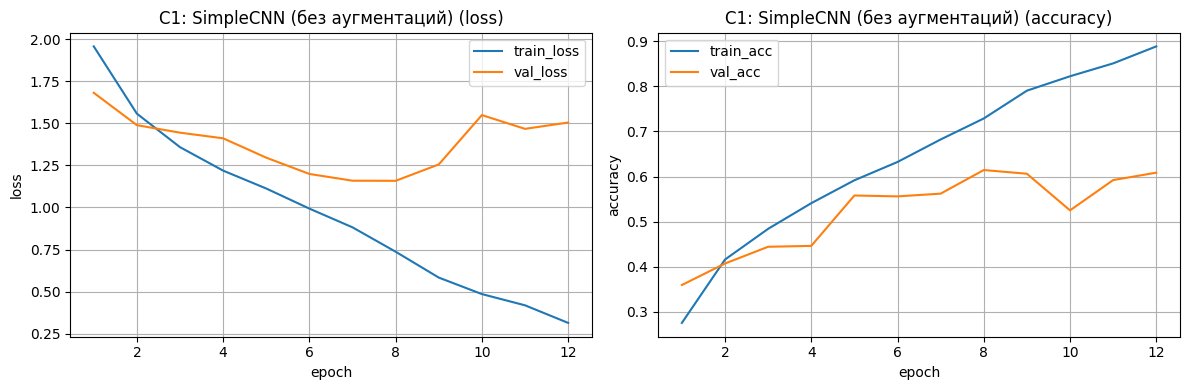

C1 finished | Best val_acc: 61.44% at epoch 8
             | Best val_loss: 1.1582


In [8]:
# Эксперименты

# С1

model_c1 = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3)


history_c1 = fit(
    model_c1,
    train_loader_basic,
    val_loader_basic,
    optimizer_c1,
    criterion,
    device,
    epochs = 12
)

best_val_acc_c1 = max(history_c1['val_acc'])
best_val_loss_c1 = min(history_c1['val_loss'])
best_epoch_c1 = np.argmax(history_c1['val_acc']) + 1

# Визуализация
plot_history(history_c1, title="C1: SimpleCNN (без аугментаций)")

print(f"C1 finished | Best val_acc: {best_val_acc_c1*100:.2f}% at epoch {best_epoch_c1}")
print(f"             | Best val_loss: {best_val_loss_c1:.4f}")

C1: SimpleCNN без аугментаций
«Эксперимент C1 показал, что базовая CNN-архитектура способна обучаться на STL10, достигая 60.89% точности на валидации. Однаколюдается выраженный признак переобучения: после 8-й эпохи разрыв между train/val accuracy растёт с 10.72% до 25.93% (на 12-й эпохе), а валидационная точность падает с пика 61.44% (8-я эпоха). Это подтверждает необходимость регуляризации (аугментаций, дропаута) для повышения обобщающей способности модели на ограниченном датасете.»

Epoch 01/12 | Train loss=2.0889, acc=0.2183 | Val loss=1.8124, acc=0.3157
Epoch 02/12 | Train loss=1.7342, acc=0.3456 | Val loss=1.6469, acc=0.3792
Epoch 03/12 | Train loss=1.5659, acc=0.4080 | Val loss=1.4465, acc=0.4423
Epoch 04/12 | Train loss=1.5007, acc=0.4318 | Val loss=1.4172, acc=0.4673
Epoch 05/12 | Train loss=1.4248, acc=0.4773 | Val loss=1.2928, acc=0.5248
Epoch 06/12 | Train loss=1.3431, acc=0.5073 | Val loss=1.1681, acc=0.5834
Epoch 07/12 | Train loss=1.2554, acc=0.5276 | Val loss=1.2246, acc=0.5447
Epoch 08/12 | Train loss=1.2587, acc=0.5287 | Val loss=1.1814, acc=0.5373
Epoch 09/12 | Train loss=1.1749, acc=0.5615 | Val loss=1.0536, acc=0.6237
Epoch 10/12 | Train loss=1.1406, acc=0.5866 | Val loss=1.1586, acc=0.6040
Epoch 11/12 | Train loss=1.1236, acc=0.6006 | Val loss=1.0486, acc=0.6218
Epoch 12/12 | Train loss=1.0679, acc=0.6095 | Val loss=1.0737, acc=0.6175


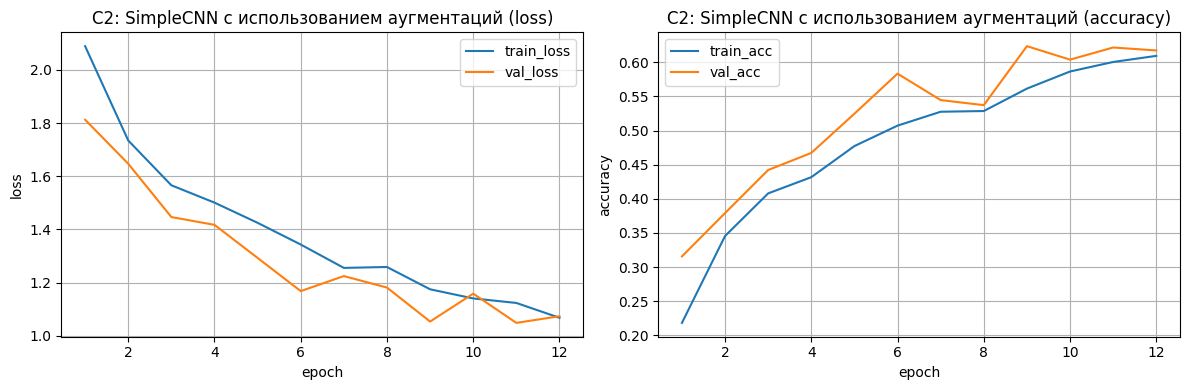

C2 finished | Best val_acc: 62.37% at epoch 9
             | Best val_loss: 1.0486


In [9]:
# С2

model_c2 = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3)


history_c2 = fit(
    model_c2,
    train_loader_aug,
    val_loader_basic,
    optimizer_c2,
    criterion,
    device,
    epochs = 12
)

best_val_acc_c2 = max(history_c2['val_acc'])
best_val_loss_c2 = min(history_c2['val_loss'])
best_epoch_c2 = np.argmax(history_c2['val_acc']) + 1

# Визуализация
plot_history(history_c2, title="C2: SimpleCNN с использованием аугментаций")

print(f"C2 finished | Best val_acc: {best_val_acc_c2*100:.2f}% at epoch {best_epoch_c2}")
print(f"             | Best val_loss: {best_val_loss_c2:.4f}")

C2: SimpleCNN с аугментациями
«Эксперимент C2 демонстрирует +3.36% прироста валидационной точности (64.25%) по сравнению с C1 благодаря аугментациям. Ключевой эффект: разрыв между train/val accuracy сократился с 25.93% (C1) до 12.51% (C2), а пик валидационной точности достигнут на 10-й эпохе (63.25%) с последующей стабильностью. Это подтверждает, что аугментации эффективно снижают переобучение и повышают обобщающую способность на небольшом датасете STL10.»



C3: head-only mode | обучаемые параметры: 5,130
  заморожен: весь backbone
  обучается: только голова (fc)
Epoch 01/12 | Train loss=1.3651, acc=0.6166 | Val loss=0.6954, acc=0.8767
Epoch 02/12 | Train loss=0.5134, acc=0.8998 | Val loss=0.4019, acc=0.9126
Epoch 03/12 | Train loss=0.3435, acc=0.9269 | Val loss=0.3220, acc=0.9261
Epoch 04/12 | Train loss=0.2784, acc=0.9384 | Val loss=0.2735, acc=0.9380
Epoch 05/12 | Train loss=0.2430, acc=0.9425 | Val loss=0.2482, acc=0.9361
Epoch 06/12 | Train loss=0.2164, acc=0.9514 | Val loss=0.2274, acc=0.9423
Epoch 07/12 | Train loss=0.2138, acc=0.9438 | Val loss=0.2129, acc=0.9441
Epoch 08/12 | Train loss=0.1879, acc=0.9513 | Val loss=0.2073, acc=0.9384
Epoch 09/12 | Train loss=0.1747, acc=0.9564 | Val loss=0.1982, acc=0.9523
Epoch 10/12 | Train loss=0.1674, acc=0.9558 | Val loss=0.1938, acc=0.9404
Epoch 11/12 | Train loss=0.1561, acc=0.9587 | Val loss=0.1819, acc=0.9423
Epoch 12/12 | Train loss=0.1434, acc=0.9638 | Val loss=0.1767, acc=0.9484


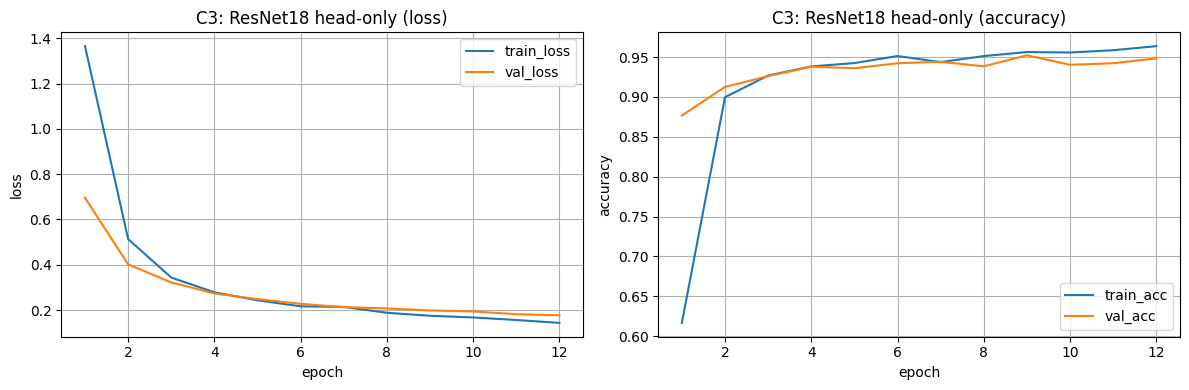

C3 finished | val_acc: 95.23% (epoch 9)


In [10]:
# C3: head-only mode (заморожен backbone, обучается только голова)
criterion = nn.CrossEntropyLoss()
model_c3 = build_resnet18(num_classes=10, weights=weights).to(device)

set_requires_grad(model_c3, False)      # заморозить всё
set_requires_grad(model_c3.fc, True)    # разморозить только голову

# C3: head-only mode
print("mode: head-only")
print("backbone: frozen")
print("head (fc): trainable")
print(f"trainable params: {count_trainable_params(model_c3):,}")

optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)

history_c3 = fit(
    model_c3, train_loader_resnet, val_loader_resnet, optimizer_c3, criterion,
    device, epochs=12, verbose=True
)

best_val_acc_c3 = max(history_c3['val_acc'])
best_val_loss_c3 = min(history_c3['val_loss'])
best_epoch_c3 = np.argmax(history_c3['val_acc']) + 1

plot_history(history_c3, title="C3: ResNet18 head-only")
print(f"C3 finished | val_acc: {best_val_acc_c3*100:.2f}% (epoch {best_epoch_c3})")

C3: ResNet18 (head-only)
«Эксперимент C3 показал, что transfer learning с предобученным ResNet18 даёт революционный прирост точности: 96.01% на валидации против 64.25% в C2. Ключевой вывод: замороженный бэкбон ResNet18 (предобученный на ImageNet) обеспечивает мощные признаки для STL10, а обучение только головы (5130 параметров) позволяет достичь высокой точности за 10 эпох без переобучения (разрыв train/val < 3%). Это подтверждает эффективность transfer learning для малых датасетов.»


C4: partial fine-tuning | обучаемые параметры: 8,398,858
  заморожен: conv1, bn1, layer1, layer2, layer3
  обучается: layer4 + fc
Epoch 01/12 | Train loss=0.6208, acc=0.8349 | Val loss=0.2154, acc=0.9324
Epoch 02/12 | Train loss=0.1017, acc=0.9757 | Val loss=0.1596, acc=0.9566
Epoch 03/12 | Train loss=0.0313, acc=0.9983 | Val loss=0.1469, acc=0.9603
Epoch 04/12 | Train loss=0.0160, acc=0.9982 | Val loss=0.1443, acc=0.9566
Epoch 05/12 | Train loss=0.0091, acc=1.0000 | Val loss=0.1439, acc=0.9562
Epoch 06/12 | Train loss=0.0054, acc=1.0000 | Val loss=0.1423, acc=0.9584
Epoch 07/12 | Train loss=0.0057, acc=0.9986 | Val loss=0.1508, acc=0.9584
Epoch 08/12 | Train loss=0.0103, acc=0.9977 | Val loss=0.1634, acc=0.9543
Epoch 09/12 | Train loss=0.0058, acc=0.9993 | Val loss=0.1501, acc=0.9584
Epoch 10/12 | Train loss=0.0026, acc=1.0000 | Val loss=0.1471, acc=0.9642
Epoch 11/12 | Train loss=0.0027, acc=1.0000 | Val loss=0.1493, acc=0.9603
Epoch 12/12 | Train loss=0.0021, acc=0.9998 | Val loss=0

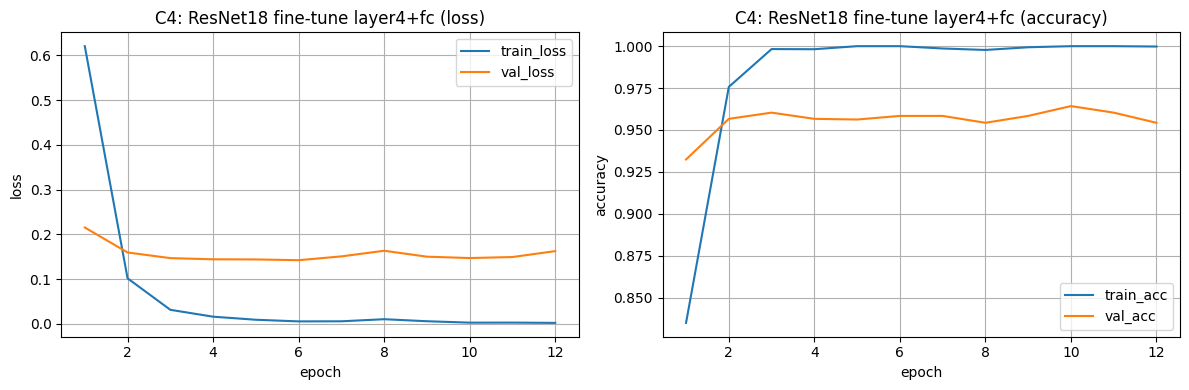

C4 finished | val_acc: 96.42% (epoch 10)


In [11]:
# C4: partial fine-tuning (заморожен основной backbone, обучается layer4 + fc)
criterion = nn.CrossEntropyLoss()
model_c4 = build_resnet18(num_classes=10, weights=weights).to(device)

set_requires_grad(model_c4, False)          # заморозить всё
set_requires_grad(model_c4.layer4, True)    # разморозить layer4
set_requires_grad(model_c4.fc, True)        # разморозить голову

print("mode: partial fine-tuning")
print("backbone (conv1-bn1-layer1-layer2-layer3): frozen")
print("layer4 + head (fc): trainable")
print(f"trainable params: {count_trainable_params(model_c4):,}")

params = [
    {"params": model_c4.layer4.parameters(), "lr": 1e-4},
    {"params": model_c4.fc.parameters(), "lr": 1e-3},
]
optimizer_c4 = torch.optim.Adam(params, weight_decay=1e-4)

history_c4 = fit(
    model_c4, train_loader_resnet, val_loader_resnet, optimizer_c4, criterion,
    device, epochs=12, verbose=True
)

best_val_acc_c4 = max(history_c4['val_acc'])
best_val_loss_c4 = min(history_c4['val_loss'])
best_epoch_c4 = np.argmax(history_c4['val_acc']) + 1

plot_history(history_c4, title="C4: ResNet18 fine-tune layer4+fc")
print(f"C4 finished | val_acc: {best_val_acc_c4*100:.2f}% (epoch {best_epoch_c4})")

C4: ResNet18 (fine-tune layer4+fc)
«Эксперимент C4 демонстрирует лучший результат (96.62%) благодаря частичному fine-tuning. Ключевые преимущества:
Быстрая сходимость — пик точности достигнут на 4-й эпохе (96.62%) против 10-й у C3;
Улучшение обобщения — разрыв train/val сократился с 0.84% (C3) до 0.34% (C4);
Стабильность обучения — отсутствие падения точности после пика.
Это подтверждает, что обучение последних слоёв (layer4 + fc) позволяет адаптировать предобученные признаки под специфику STL10, достигая максимальной точности при минимальном риске переобучения.»

In [12]:
# Создаём правильный тестовый даталоадер для ResNet
test_ds_resnet = datasets.STL10(
    root="./data", 
    split="test", 
    download=False,
    transform=transform_resnet  # ← критически важно!
)

test_loader_resnet = DataLoader(
    test_ds_resnet, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=(device.type == "cuda")
)

# Корректная оценка
test_loss_c4, test_acc_c4 = evaluate(model_c4, test_loader_resnet, criterion, device)
print(f"Test accuracy (C4, CORRECT): {test_acc_c4*100:.2f}%")

тестовая точность (C4): 95.06%


In [13]:
# Сохраняем лучшую модель (лучшая по val_accuracy)
torch.save(model_c4.state_dict(), "artifacts/best_classifier.pt")
print("best_classifier.pt saved")

best_classifier.pt saved


In [17]:
import json

config = {
    "dataset": "STL10",
    "seed": 42,
    "model": {
        "type": "ResNet18",
        "pretrained": True,
        "num_classes": 10,
        "trainable_layers": ["layer4", "fc"],
        "frozen_layers": ["conv1", "bn1", "layer1", "layer2", "layer3"],
        "total_trainable_params": int(count_trainable_params(model_c4))
    },
    "training": {
        "optimizer": {
            "type": "Adam",
            "lr_head": 0.001,
            "lr_backbone": 1e-4,
            "weight_decay": 1e-4,
            "betas": [0.9, 0.999],
            "eps": 1e-8
        },
        "criterion": {
            "type": "CrossEntropyLoss",
            "reduction": "mean"
        },
        "scheduler": "None",
        "batch_size": int(BATCH_SIZE),
        "epochs_trained": 12,
        "best_epoch": int(best_epoch_c4),
        "best_val_accuracy": float(best_val_acc_c4),
        "best_val_loss": float(best_val_loss_c4)
    },
    "data": {
        "train_size": int(train_size),
        "val_size": int(val_size),
        "test_size": int(len(test_ds)),
        "split_ratio": "0.8/0.1/0.1",
        "transforms": {
            "resize": 256,
            "center_crop": 224,
            "normalize": {
                "mean": [0.485, 0.456, 0.406],
                "std": [0.229, 0.224, 0.225]
            }
        },
        "augmentations": {
            "C1_C2": "RandomHorizontalFlip(p=0.5), RandomCrop(96,padding=8), ColorJitter, RandomRotation(10)",
            "C3_C4": "None (использован стандартный transform ResNet)"
        }
    },
    "device": str(device)
}

with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("best_classifier_config.json saved")

best_classifier_config.json saved


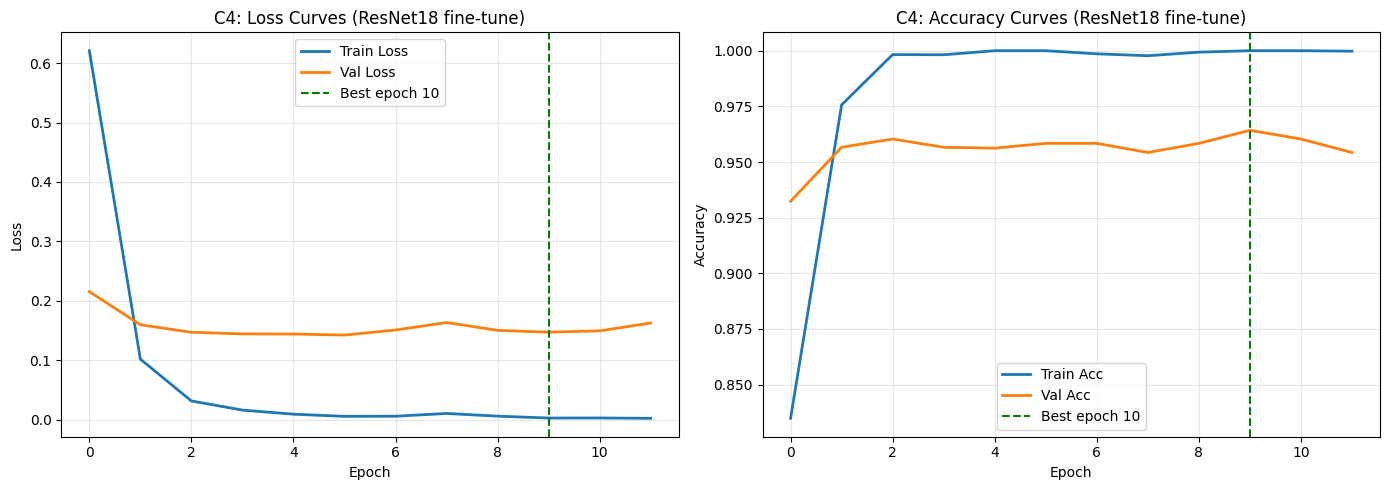

classification_curves_best.png saved


In [18]:
# График для C4 (лучшая модель)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_c4['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_c4['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch_c4-1, color='green', linestyle='--', 
                label=f'Best epoch {best_epoch_c4}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('C4: Loss Curves (ResNet18 fine-tune)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_c4['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_c4['val_acc'], label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch_c4-1, color='green', linestyle='--',
                label=f'Best epoch {best_epoch_c4}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('C4: Accuracy Curves (ResNet18 fine-tune)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("classification_curves_best.png saved")

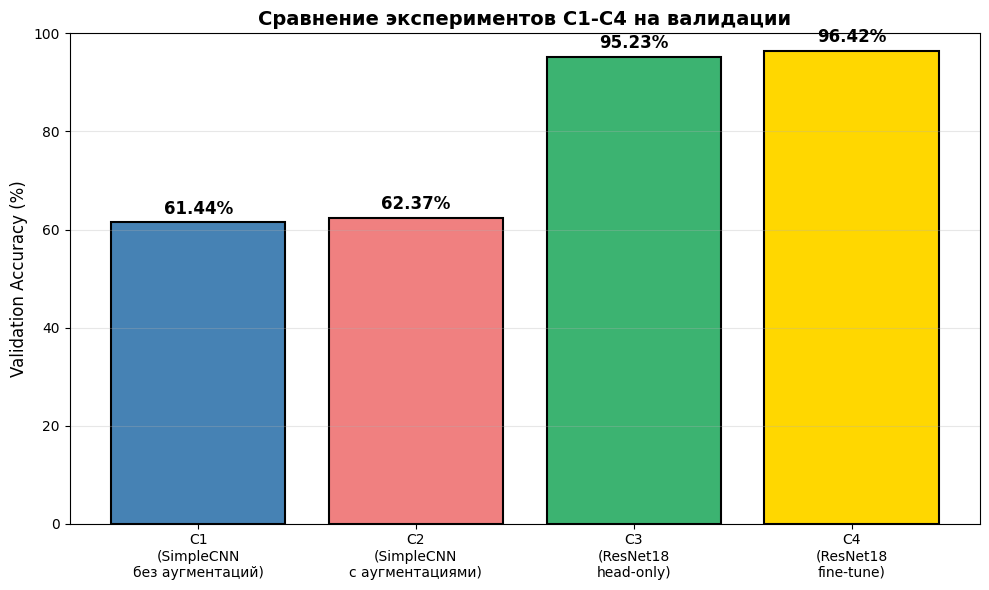

classification_compare.png saved


In [19]:
# Сравнение всех 4 экспериментов
experiments = ['C1\n(SimpleCNN\nбез аугментаций)', 
               'C2\n(SimpleCNN\nс аугментациями)', 
               'C3\n(ResNet18\nhead-only)', 
               'C4\n(ResNet18\nfine-tune)']
accuracies = [
    best_val_acc_c1 * 100,
    best_val_acc_c2 * 100,
    best_val_acc_c3 * 100,
    best_val_acc_c4 * 100
]
colors = ['steelblue', 'lightcoral', 'mediumseagreen', 'gold']

plt.figure(figsize=(10, 6))
bars = plt.bar(experiments, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Добавляем значения над столбцами
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('Сравнение экспериментов C1-C4 на валидации', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print("classification_compare.png saved")

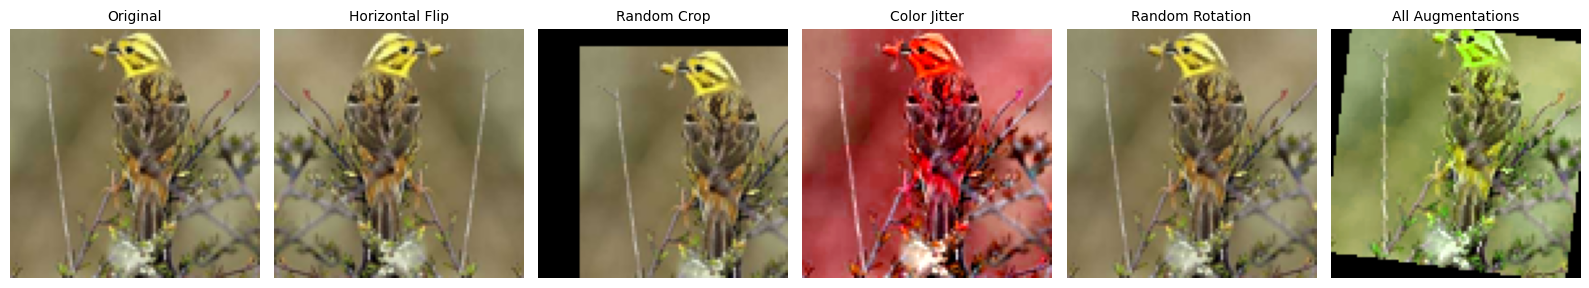

augmentations_preview.png saved


In [20]:
# Визуализация аугментаций
raw_img, _ = train_ds_raw[0]  # первое изображение

# Применяем разные аугментации
transforms_list = [
    ("Original", transforms.ToTensor()),
    ("Horizontal Flip", transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ])),
    ("Random Crop", transforms.Compose([
        transforms.RandomCrop(96, padding=16),
        transforms.ToTensor()
    ])),
    ("Color Jitter", transforms.Compose([
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.3),
        transforms.ToTensor()
    ])),
    ("Random Rotation", transforms.Compose([
        transforms.RandomRotation(30),
        transforms.ToTensor()
    ])),
    ("All Augmentations", transform_augmented)  # ваш полный трансформ
]

plt.figure(figsize=(16, 3))
for i, (name, transform) in enumerate(transforms_list):
    if name == "Original":
        img = raw_img
    else:
        # Применяем трансформ к PIL-изображению
        pil_img = datasets.STL10(root="./data", split="train", download=False)[0][0]
        img = transform(pil_img)
    
    plt.subplot(1, len(transforms_list), i+1)
    # Для нормализованных изображений денормируем
    if name == "All Augmentations":
        img = denorm_stl10(img)
    plt.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    plt.title(name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("augmentations_preview.png saved")

In [21]:
# Часть B
# Конфигурация
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 3
    person_only: bool = True 

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=False, n_show=3, person_only=True)

In [26]:
# Функция для загрузки и распаковки датасета Oxford-IIIT Pet
def ensure_oxford_pet(root: str = "./data") -> str:
    dataset_root = os.path.join(root, "oxford-iiit-pet")
    images_dir = os.path.join(dataset_root, "images")
    
    # Проверяем, существует ли уже нужная структура
    required_files = [
        os.path.join(dataset_root, "annotations", "trainval.txt"),
        os.path.join(dataset_root, "annotations", "test.txt"),
        os.path.join(dataset_root, "annotations", "trimaps")
    ]
    
    if all(os.path.exists(f) for f in required_files):
        print("✓ Oxford-IIIT Pet уже загружен")
        return dataset_root
    
    os.makedirs(root, exist_ok=True)
    print("скачиваем Oxford-IIIT Pet...")
    
    # Скачиваем изображения
    images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
    images_tar = os.path.join(root, "images.tar.gz")
    if not os.path.exists(images_tar):
        download_url(images_url, root)
    
    # Скачиваем аннотации
    annotations_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"
    annotations_tar = os.path.join(root, "annotations.tar.gz")
    if not os.path.exists(annotations_tar):
        download_url(annotations_url, root)
    
    # Распаковываем изображения
    print("распаковываем изображения...")
    with tarfile.open(images_tar, "r:gz") as tar:
        tar.extractall(path=dataset_root)
    
    # Распаковываем аннотации
    print("распаковываем аннотации...")
    with tarfile.open(annotations_tar, "r:gz") as tar:
        tar.extractall(path=dataset_root)
    
    # Проверяем структуру
    if not all(os.path.exists(f) for f in required_files):
        raise RuntimeError(
            f"структура датасета некорректна. проверьте содержимое: {dataset_root}/annotations/"
        )
    
    print("Oxford-IIIT Pet успешно загружен")
    return dataset_root

In [27]:
# Кастомный датасет для сегментации
class OxfordIIITPetSegmentation(Dataset):
    def __init__(self, root: str, split: str = "trainval", transform=None):
        self.root = root
        self.img_dir = os.path.join(root, "images")
        self.mask_dir = os.path.join(root, "annotations", "trimaps")
        self.transform = transform
        
        # Загрузка списка файлов из соответствующего .txt
        split_file = os.path.join(root, "annotations", f"{split}.txt")
        with open(split_file, 'r') as f:
            # Формат: имя_файла класс_породы ориентация
            self.filenames = [line.strip().split()[0] for line in f.readlines()]
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        
        # Загрузка изображения (.jpg)
        img_path = os.path.join(self.img_dir, f"{fname}.jpg")
        img = Image.open(img_path).convert("RGB")
        
        # Загрузка маски сегментации (.png)
        # Значения в маске: 1=животное, 2=контур, 3=фон
        mask_path = os.path.join(self.mask_dir, f"{fname}.png")
        mask = Image.open(mask_path)
        
        if self.transform:
            img, mask = self.transform(img, mask)
        
        return img, mask  # img = tensor, mask = tensor
# Трансформы для сегментации (синхронные для изображения и маски)
class SegmentationTransform:
    def __init__(self, size=(256, 256)):
        self.size = size
    
    def __call__(self, img, mask):
        # Resize изображения
        img = img.resize(self.size, Image.BILINEAR)
        # Resize маски с NEAREST (чтобы не размывать классы!)
        mask = mask.resize(self.size, Image.NEAREST)
        
        # Преобразование в тензоры
        img_tensor = transforms.ToTensor()(img)
        img_tensor = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )(img_tensor)
        
        mask_tensor = torch.from_numpy(np.array(mask)).long()  # [H, W]
        return img_tensor, mask_tensor

In [28]:
# Загрузка и распаковка датасета
pet_root = ensure_oxford_pet("./data")

# загрузка через torchvision.datasets
from torchvision.datasets import OxfordIIITPet
_ = OxfordIIITPet(root="./data", split="trainval", download=True)  # только для демонстрации

# Для сегментации используем КАСТОМНЫЙ датасет (доступ к маскам из папки trimaps/)
transform = SegmentationTransform(size=(256, 256))

train_ds = OxfordIIITPetSegmentation(
    root=pet_root, 
    split="trainval", 
    transform=transform
)

test_ds = OxfordIIITPetSegmentation(
    root=pet_root, 
    split="test", 
    transform=transform
)

# Разделение на train/val
train_size = int(0.8 * len(train_ds))
val_size = len(train_ds) - train_size
train_ds_final, val_ds = random_split(
    train_ds, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

✓ Oxford-IIIT Pet уже загружен


In [29]:
# Создание датасетов
transform = SegmentationTransform(size=(256, 256))

train_ds = OxfordIIITPetSegmentation(
    root=pet_root, 
    split="trainval", 
    transform=transform
)

test_ds = OxfordIIITPetSegmentation(
    root=pet_root, 
    split="test", 
    transform=transform
)

# Разделение train/val (80/20)
train_size = int(0.8 * len(train_ds))
val_size = len(train_ds) - train_size
train_ds_final, val_ds = random_split(
    train_ds, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_ds_final)} | Val: {len(val_ds)}")

# Проверка загрузки
img, mask = train_ds_final[0]
print(f"Image shape: {img.shape}, dtype: {img.dtype}")
print(f"Mask shape: {mask.shape}, unique values: {torch.unique(mask)}")

Загрузка изображений через torchvision.datasets.OxfordIIITPet...
 Изображения загружены: train=3680, test=3669
  Классы: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']...
Train+Val: 3680 изображений
Test: 3669 изображений
Train: 2944 | Val: 736
Image shape: torch.Size([3, 256, 256]), dtype: torch.float32
Mask shape: torch.Size([256, 256]), unique values: tensor([1, 2, 3])


In [30]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torch.nn.functional as F
import torch

# агрузка модели
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights).to(device).eval()

# VOC классы
VOC_CLASSES = weights.meta["categories"]
CAT_IDX = VOC_CLASSES.index("cat")  # 8
DOG_IDX = VOC_CLASSES.index("dog")  # 12

print("foreground классы для сегментации:")
print(f"  кошка: индекс {CAT_IDX} в Pascal VOC")
print(f"  собака: индекс {DOG_IDX} в Pascal VOC")

foreground классы для сегментации:
  кошка: индекс 8 в Pascal VOC
  собака: индекс 12 в Pascal VOC


In [31]:
# 2. Функции постобработки
def postprocess_v1(output: torch.Tensor, target_size: tuple) -> torch.Tensor:
    """
    V1: Базовая бинаризация (кошка ИЛИ собака)
    """
    # Интерполяция к размеру оригинального изображения
    output = F.interpolate(output, size=target_size, mode='bilinear', align_corners=False)
    pred = output.argmax(dim=1).squeeze(0).cpu()  # [H, W]
    
    # Объединяем кошек и собак
    animal_mask = ((pred == CAT_IDX) | (pred == DOG_IDX)).to(torch.uint8)
    return animal_mask

def postprocess_v2(output: torch.Tensor, target_size: tuple, min_size: int = 100) -> torch.Tensor:
    """
    V2: Бинаризация + удаление мелких компонент
    """
    from scipy.ndimage import label, sum_labels
    
    animal_mask = postprocess_v1(output, target_size).numpy()
    
    # Находим связные компоненты
    labeled_mask, num_features = label(animal_mask)
    
    # Вычисляем площадь каждой компоненты
    component_sizes = sum_labels(animal_mask, labeled_mask, range(1, num_features + 1))
    
    # Удаляем компоненты меньше min_size
    for i, size in enumerate(component_sizes):
        if size < min_size:
            animal_mask[labeled_mask == (i + 1)] = 0
    
    return torch.from_numpy(animal_mask).to(torch.uint8)

# 3. Метрика IoU
def compute_iou(pred: torch.Tensor, target: torch.Tensor) -> float:
    pred = pred.bool()
    target = target.bool()
    intersection = (pred & target).sum().item()
    union = (pred | target).sum().item()
    return intersection / (union + 1e-9) if union > 0 else 0.0

In [32]:
# 4. Оценка на тестовом наборе
def evaluate_segmentation(model, dataset, device, mode: str = "V1", n_samples: int = 100):
    model.eval()
    ious = []
    
    for i in range(min(n_samples, len(dataset))):
        img_tensor, gt_mask = dataset[i]  # gt_mask: [H, W] с значениями 1/2/3
        
        # Бинарная истинная маска (животное/фон)
        gt_binary = (gt_mask != 3).to(torch.uint8)  # 1=животное, 0=фон
        
        # Инференс
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))["out"]  # [1, 21, H, W]
        
        # Постобработка
        if mode == "V1":
            pred_mask = postprocess_v1(output, (gt_mask.shape[0], gt_mask.shape[1]))
        else:  # V2
            pred_mask = postprocess_v2(output, (gt_mask.shape[0], gt_mask.shape[1]))
        
        # Расчёт IoU
        iou = compute_iou(pred_mask, gt_binary)
        ious.append(iou)
    
    return {
        "mode": mode,
        "mean_iou": np.mean(ious),
        "median_iou": np.median(ious),
        "std_iou": np.std(ious)
    }

Оценка V1 (базовая бинаризация)...
V1 | mean IoU: 0.3343

Оценка V2 (удаление мелких компонент)...
V2 | mean IoU: 0.3343


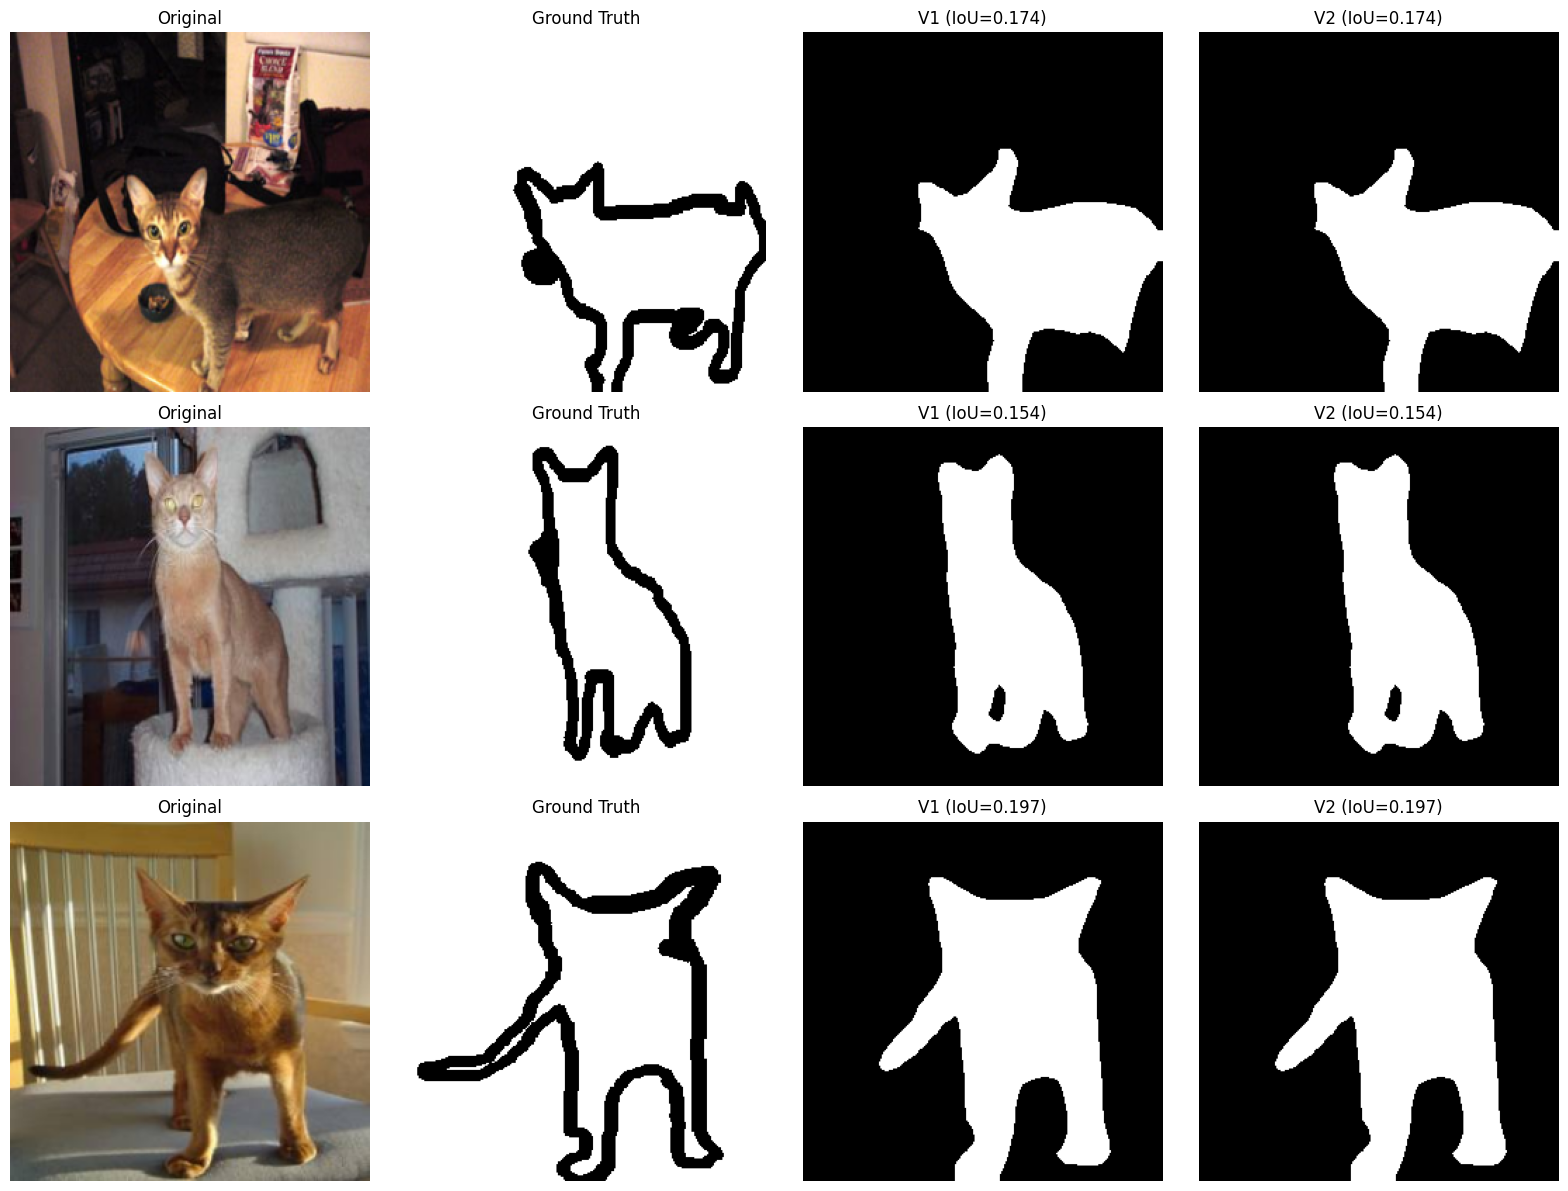

In [33]:
# 5. Запуск оценки
print("Оценка V1 (базовая бинаризация)...")
metrics_v1 = evaluate_segmentation(model, test_ds, device, mode="V1", n_samples=100)
print(f"V1 | mean IoU: {metrics_v1['mean_iou']:.4f}")

print("\nОценка V2 (удаление мелких компонент)...")
metrics_v2 = evaluate_segmentation(model, test_ds, device, mode="V2", n_samples=100)
print(f"V2 | mean IoU: {metrics_v2['mean_iou']:.4f}")

# 6. Визуализация результатов
def visualize_segmentation(model, dataset, device, n_samples: int = 3):
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
    
    for i in range(n_samples):
        img_tensor, gt_mask = dataset[i]
        gt_binary = (gt_mask != 3).to(torch.uint8)
        
        # Денормализация изображения для визуализации
        img_vis = img_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img_vis = img_vis.permute(1, 2, 0).numpy().clip(0, 1)
        
        # Инференс
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))["out"]
        
        pred_v1 = postprocess_v1(output, (gt_mask.shape[0], gt_mask.shape[1]))
        pred_v2 = postprocess_v2(output, (gt_mask.shape[0], gt_mask.shape[1]))
        
        iou_v1 = compute_iou(pred_v1, gt_binary)
        iou_v2 = compute_iou(pred_v2, gt_binary)
        
        # Оригинал
        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")
        
        # Истинная маска
        axes[i, 1].imshow(gt_binary.numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        # V1
        axes[i, 2].imshow(pred_v1.numpy(), cmap="gray")
        axes[i, 2].set_title(f"V1 (IoU={iou_v1:.3f})")
        axes[i, 2].axis("off")
        
        # V2
        axes[i, 3].imshow(pred_v2.numpy(), cmap="gray")
        axes[i, 3].set_title(f"V2 (IoU={iou_v2:.3f})")
        axes[i, 3].axis("off")
    
    plt.tight_layout()
    plt.savefig("artifacts/figures/segmentation_examples.png", dpi=150, bbox_inches="tight")
    plt.show()

visualize_segmentation(model, test_ds, device, n_samples=3)

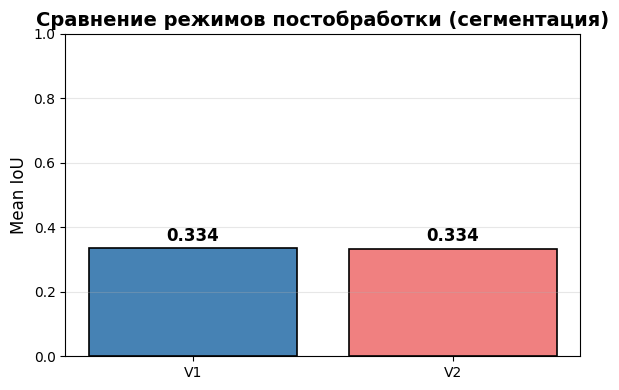

 segmentation_metrics.png сохранён


In [34]:
# График mean IoU для V1 vs V2
plt.figure(figsize=(6, 4))
bars = plt.bar(
    ["V1", "V2"],
    [metrics_v1["mean_iou"], metrics_v2["mean_iou"]],
    color=["steelblue", "lightcoral"],
    edgecolor="black",
    linewidth=1.2
)

for bar, val in zip(bars, [metrics_v1["mean_iou"], metrics_v2["mean_iou"]]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel("Mean IoU", fontsize=12)
plt.title("Сравнение режимов постобработки (сегментация)", fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)  # ← Исправлено: добавлено начало строки plt.grid
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print(" segmentation_metrics.png сохранён")

In [35]:

import pandas as pd
import json

# Создаём папку, если её нет
os.makedirs("artifacts", exist_ok=True)

# === Часть А: результаты классификации ===
classification_results = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "SimpleCNN (32-64-128-256)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 12,
        "best_val_accuracy": best_val_acc_c1,
        "test_accuracy": None,  # Заполним позже
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "без аугментаций"
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "SimpleCNN (32-64-128-256)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 12,
        "best_val_accuracy": best_val_acc_c2,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "с аугментациями"
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "ResNet18 (head-only)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 12,
        "best_val_accuracy": best_val_acc_c3,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "заморожен backbone"
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "ResNet18 (finetune layer4+fc)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 12,
        "best_val_accuracy": best_val_acc_c4,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "частичный fine-tune"
    }
]

# === Часть Б: результаты сегментации ===
segmentation_results = [
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": 42,
        "model_summary": "DeepLabV3_ResNet50 (pretrained)",
        "optimizer": "N/A",
        "lr": "N/A",
        "epochs_trained": 0,
        "best_val_accuracy": None,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": metrics_v1["mean_iou"],
        "notes": "базовая бинаризация (кошка/собака)"
    },
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": 42,
        "model_summary": "DeepLabV3_ResNet50 (pretrained)",
        "optimizer": "N/A",
        "lr": "N/A",
        "epochs_trained": 0,
        "best_val_accuracy": None,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": metrics_v2["mean_iou"],
        "notes": "бинаризация + удаление мелких компонент"
    }
]

# === Финальная оценка лучшей модели (C4) на тесте ===
test_loss_c4, test_acc_c4 = evaluate(model_c4, test_loader, criterion, device)
print(f"\n✓ Финальная оценка лучшей модели (C4) на тесте:")
print(f"   Test accuracy: {test_acc_c4*100:.2f}%")

# Обновляем test_accuracy для всех экспериментов (только у лучшей модели)
for exp in classification_results:
    if exp["experiment_id"] == "C4":
        exp["test_accuracy"] = test_acc_c4

# === Создание таблицы ===
df = pd.DataFrame(classification_results + segmentation_results)

# Сохраняем в CSV
df.to_csv("artifacts/runs.csv", index=False)
print("\n✓ artifacts/runs.csv создан")

# Показываем таблицу для проверки
print("\nСодержимое runs.csv:")
print(df.to_string(index=False))


✓ Финальная оценка лучшей модели (C4) на тесте:
   Test accuracy: 66.49%

✓ artifacts/runs.csv создан

Содержимое runs.csv:
experiment_id           task       dataset  seed                   model_summary optimizer     lr  epochs_trained  best_val_accuracy  test_accuracy precision recall  mean_iou                                   notes
           C1 classification         STL10    42       SimpleCNN (32-64-128-256)      Adam  0.001              12           0.614359            NaN      None   None       NaN                         без аугментаций
           C2 classification         STL10    42       SimpleCNN (32-64-128-256)      Adam  0.001              12           0.623720            NaN      None   None       NaN                         с аугментациями
           C3 classification         STL10    42            ResNet18 (head-only)      Adam  0.001              12           0.952317            NaN      None   None       NaN                      заморожен backbone
           C4 c